In [3]:
import pandas as pd
import numpy as np
import os

In [ ]:


if os.path.exists("../data/processed/X_raw.npy"):
    print("Ucitavam vec obradjene podatke...")
    X = np.load("../data/processed/X_raw.npy")
else:
    print("Učitavam raw podatke...")
    data = pd.read_csv("../data/raw/GSE115469_Data.csv", index_col=0)
    X = data.to_numpy(dtype=np.float32)
    X = X.T
    del data

Ucitavam vec obradjene podatke...


In [5]:

print(X.shape)

(8444, 20007)


In [9]:
np.save("../data/processed/X_raw.npy", X)

In [10]:
X = np.load("../data/processed/X_raw.npy")

In [11]:
X[:5]

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.31475955, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], dtype=float32)

In [6]:
variances = np.var(X, axis=0)
k = 3000
top_genes = np.argsort(variances)[-k:]

X = X[:, top_genes]

print(X.shape)


(8444, 3000)


In [7]:
from sklearn.preprocessing import StandardScaler   
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)
del X

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled).astype(np.float32)

print(X_pca.shape)

(8444, 50)


In [9]:
pca.explained_variance_ratio_.sum()

0.25720343

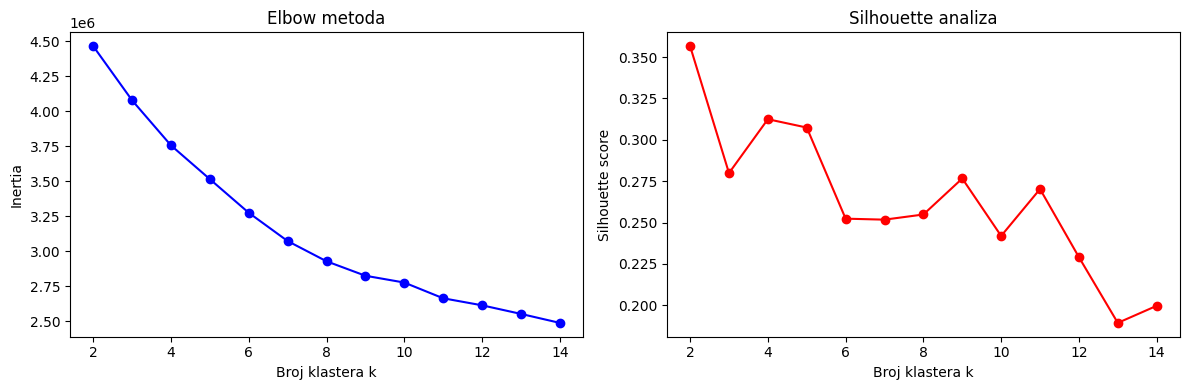

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib import pyplot as plt

inertias = []
silhouettes = []
K_range = range(2, 15)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels, sample_size=2000))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel("Broj klastera k")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow metoda")

ax2.plot(K_range, silhouettes, 'ro-')
ax2.set_xlabel("Broj klastera k")
ax2.set_ylabel("Silhouette score")
ax2.set_title("Silhouette analiza")

plt.tight_layout()
plt.show()

In [11]:
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_pca)

np.save("../data/processed/cluster_labels.npy", cluster_labels)

2026-02-23 09:49:56.820332: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-23 09:49:56.913792: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-23 09:49:56.940288: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-23 09:49:57.099210: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-23 09:49:59.736924: W tensorflow/compiler/tf2

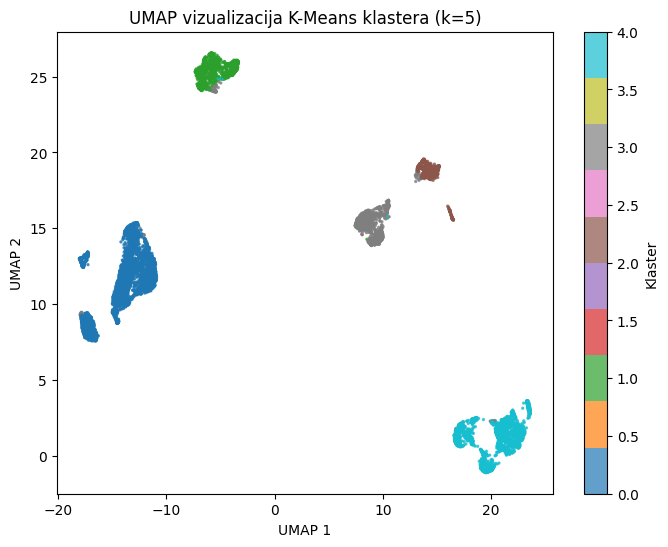

In [12]:
import umap

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_pca)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], 
                      c=cluster_labels, cmap='tab10', s=2, alpha=0.7)
plt.colorbar(scatter, label='Klaster')
plt.title('UMAP vizualizacija K-Means klastera (k=5)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

np.save("../data/processed/X_umap.npy", X_umap)

In [13]:
from sklearn.cluster import AgglomerativeClustering

linkages = ['ward', 'complete', 'average']

for linkage in linkages:
    agg = AgglomerativeClustering(n_clusters=5, linkage=linkage)
    labels = agg.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels, sample_size=2000)
    print(f"linkage={linkage}: silhouette={score:.4f}")

linkage=ward: silhouette=0.3182
linkage=complete: silhouette=0.8492
linkage=average: silhouette=0.8829


In [14]:
for linkage in ['ward', 'complete', 'average']:
    agg = AgglomerativeClustering(n_clusters=5, linkage=linkage)
    labels = agg.fit_predict(X_pca)
    print(f"\nlinkage={linkage}:")
    print(pd.Series(labels).value_counts().sort_index())


linkage=ward:
0    3509
1     604
2    1094
3    1087
4    2150
Name: count, dtype: int64

linkage=complete:
0    8440
1       1
2       1
3       1
4       1
Name: count, dtype: int64

linkage=average:
0    8440
1       1
2       1
3       1
4       1
Name: count, dtype: int64


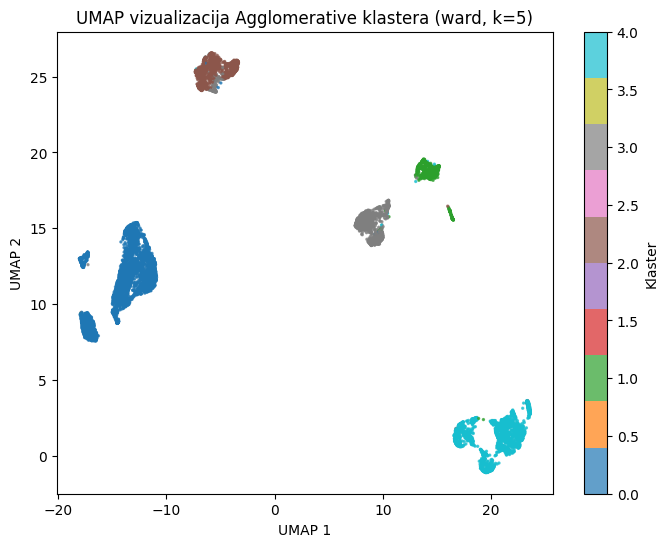

In [15]:
agg_final = AgglomerativeClustering(n_clusters=5, linkage='ward')
agg_labels = agg_final.fit_predict(X_pca)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1],
                      c=agg_labels, cmap='tab10', s=2, alpha=0.7)
plt.colorbar(scatter, label='Klaster')
plt.title('UMAP vizualizacija Agglomerative klastera (ward, k=5)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

np.save("../data/processed/agg_labels.npy", agg_labels)

In [16]:
X_raw = np.load("../data/processed/X_raw.npy")
print(X_raw.shape)

(8444, 20007)


In [18]:
def prepare_and_cluster(X, n_gens, use_pca=True, k=5):
    
    variances = np.var(X, axis=0)
    top_genes = np.argsort(variances)[-n_gens:]
    X_sel = X[:, top_genes]
    
    X_scaled = StandardScaler().fit_transform(X_sel).astype(np.float32)
    
    if use_pca:
        X_final = PCA(n_components=50, random_state=42).fit_transform(X_scaled).astype(np.float32)
        name = f"Top{n_gens}_PCA"
    else:
        X_final = X_scaled
        name = f"Top{n_gens}_bezPCA"
    
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_final)
    score = silhouette_score(X_final, labels, sample_size=2000)
    
    print(f"{name}: silhouette={score:.4f}")
    return name, score, labels

In [19]:
results = {}

for n_genes in [500, 1000, 3000]:
    name, score, labels = prepare_and_cluster(X_raw, n_genes, use_pca=True)
    results[name] = score

for n_genes in [500, 3000]:
    name, score, labels = prepare_and_cluster(X_raw, n_genes, use_pca=False)
    results[name] = score

print("\n=== COMPARISON ===")
for name, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {score:.4f}")

Top500_PCA: silhouette=0.1851
Top1000_PCA: silhouette=0.1860
Top3000_PCA: silhouette=0.3117
Top500_bezPCA: silhouette=0.1165
Top3000_bezPCA: silhouette=-0.0027

=== COMPARISON ===
Top3000_PCA: 0.3117
Top1000_PCA: 0.1860
Top500_PCA: 0.1851
Top500_bezPCA: 0.1165
Top3000_bezPCA: -0.0027


In [20]:
from sklearn.cluster import BisectingKMeans

configs = [
    ("Top500_PCA", 500, True),
    ("Top3000_PCA", 3000, True),
    ("Top3000_noPCA", 3000, False),
]

bisect_results = {}

for name, n_genes, use_pca in configs:
    variances = np.var(X_raw, axis=0)
    top_genes = np.argsort(variances)[-n_genes:]
    X_sel = X_raw[:, top_genes]
    
    X_scaled = StandardScaler().fit_transform(X_sel).astype(np.float32)
    
    if use_pca:
        X_final = PCA(n_components=50, random_state=42).fit_transform(X_scaled).astype(np.float32)
    else:
        X_final = X_scaled
    
    model = BisectingKMeans(n_clusters=5, random_state=42)
    labels = model.fit_predict(X_final)
    score = silhouette_score(X_final, labels, sample_size=2000)
    
    bisect_results[name] = score
    print(f"{name}: silhouette={score:.4f}")

print("\n=== BISECTING KMEANS COMPARISON ===")
for name, score in sorted(bisect_results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {score:.4f}")

Top500_PCA: silhouette=0.1646
Top3000_PCA: silhouette=0.2826
Top3000_noPCA: silhouette=0.0246

=== BISECTING KMEANS COMPARISON ===
Top3000_PCA: 0.2826
Top500_PCA: 0.1646
Top3000_noPCA: 0.0246


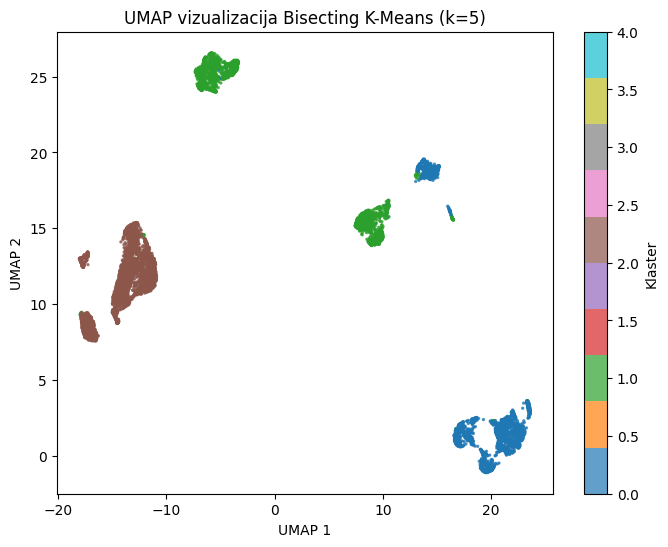

In [21]:
variances = np.var(X_raw, axis=0)
top_genes = np.argsort(variances)[-3000:]
X_sel = X_raw[:, top_genes]
X_scaled_bisect = StandardScaler().fit_transform(X_sel).astype(np.float32)
X_pca_bisect = PCA(n_components=50, random_state=42).fit_transform(X_scaled_bisect).astype(np.float32)

bisect_final = BisectingKMeans(n_clusters=5, random_state=42)
bisect_labels = bisect_final.fit_predict(X_pca_bisect)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1],
                      c=bisect_labels, cmap='tab10', s=2, alpha=0.7)
plt.colorbar(scatter, label='Klaster')
plt.title('UMAP vizualizacija Bisecting K-Means (k=5)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

np.save("../data/processed/bisect_labels.npy", bisect_labels)